# Кластеризация

In [1]:
import pandas as pd
import numpy as np

from datetime import datetime

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, OPTICS
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.neighbors import NearestNeighbors
from kneed import KneeLocator
from yellowbrick.cluster import KElbowVisualizer
from sklearn.decomposition import PCA

import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use('default')
from matplotlib.colors import ListedColormap
color = "#FF0000"
colors = ListedColormap(['#FF8C00', '#00E5FF', '#6A0DAD', '#00AF50', '#E3008C'])

BOLD = '\033[1m'
END = '\033[0m'

import warnings
warnings.filterwarnings('ignore')

## 1 Сбор и первичный анализ данных

### 1.1 Сбор данных

In [2]:
df_channels = pd.read_csv('channels.csv', encoding='latin-1')
df_channels

,rank,Youtuber,subscribers,video views,category,Title,uploads,Country,Abbreviation,channel_type,...,subscribers_for_last_30_days,created_year,created_month,created_date,Gross tertiary education enrollment (%),Population,Unemployment rate,Urban_population,Latitude,Longitude
0,1,T-Series,245000000,2.280000e+11,Music,T-Series,20082,India,IN,Music,...,2000000.0,2006.0,Mar,13.0,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880
1,2,YouTube Movies,170000000,0.000000e+00,Film & Animation,youtubemovies,1,United States,US,Games,...,NaN,2006.0,Mar,5.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
2,3,MrBeast,166000000,2.836884e+10,Entertainment,MrBeast,741,United States,US,Entertainment,...,8000000.0,2012.0,Feb,20.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
3,4,Cocomelon - Nursery Rhymes,162000000,1.640000e+11,Education,Cocomelon - Nursery Rhymes,966,United States,US,Education,...,1000000.0,2006.0,Sep,1.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
4,5,SET India,159000000,1.480000e+11,Shows,SET India,116536,India,IN,Entertainment,...,1000000.0,2006.0,Sep,20.0,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
990,991,Natan por Aï¿,12300000,9.029610e+09,Sports,Natan por Aï¿,1200,Brazil,BR,Entertainment,...,700000.0,2017.0,Feb,12.0,51.3,2.125594e+08,12.08,183241641.0,-14.235004,-51.925280
991,992,Free Fire India Official,12300000,1.674410e+09,People & Blogs,Free Fire India Official,1500,India,IN,Games,...,300000.0,2018.0,Sep,14.0,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880
992,993,Panda,12300000,2.214684e+09,NaN,HybridPanda,2452,United Kingdom,GB,Games,...,1000.0,2006.0,Sep,11.0,60.0,6.683440e+07,3.85,55908316.0,55.378051,-3.435973
993,994,RobTopGames,12300000,3.741235e+08,Gaming,RobTopGames,39,Sweden,SE,Games,...,100000.0,2012.0,May,9.0,67.0,1.028545e+07,6.48,9021165.0,60.128161,18.643501


In [3]:
print(f"\nРазмерность (количество наблюдений, количество признаков): {df_channels.shape}")
print(f"\nТипы данных:\n{df_channels.dtypes}")

missing = df_channels.isnull().sum()
missing_percent = (missing / len(df_channels)) * 100
missing_df = pd.DataFrame({'Количество пропусков': missing, 'Доля (%)': missing_percent})
missing_df = missing_df[missing_df['Количество пропусков'] > 0].sort_values('Доля (%)', ascending=False)

if not missing_df.empty:
    print(f"\nПропуски в данных:\n{missing_df}")
else:
    print("\nПропуски в данных отсутствуют.")


Размерность (количество наблюдений, количество признаков): (995, 28)

Типы данных:
rank                                         int64
Youtuber                                       str
subscribers                                  int64
video views                                float64
category                                       str
Title                                          str
uploads                                      int64
Country                                        str
Abbreviation                                   str
channel_type                                   str
video_views_rank                           float64
country_rank                               float64
channel_type_rank                          float64
video_views_for_the_last_30_days           float64
lowest_monthly_earnings                    float64
highest_monthly_earnings                   float64
lowest_yearly_earnings                     float64
highest_yearly_earnings                    float6

In [4]:
df_channels = df_channels.dropna(subset=['created_year', 'created_month', 'created_date'])

month_map = {
    'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4, 'May': 5, 'Jun': 6,
    'Jul': 7, 'Aug': 8, 'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12
}

df_channels['created_time'] = pd.to_datetime({
    'year': df_channels['created_year'].astype(int),
    'month': df_channels['created_month'].map(month_map),
    'day': df_channels['created_date'].astype(int)
})

df_channels = df_channels[df_channels['created_time']!='1970-01-01']

df_channels['age_days'] = (datetime(2023, 12, 31) - df_channels['created_time']).dt.days

df_channels[['created_time', 'age_days']]

,created_time,age_days
0,2006-03-13,6502
1,2006-03-05,6510
2,2012-02-20,4332
3,2006-09-01,6330
4,2006-09-20,6311
...,...,...
990,2017-02-12,2513
991,2018-09-14,1934
992,2006-09-11,6320
993,2012-05-09,4253


In [5]:
cluster_features = [
    'category', 'channel_type', 'age_days',
    'subscribers', 'video views', 'uploads',
    
    'video_views_for_the_last_30_days',
    'subscribers_for_last_30_days',
    
    'highest_monthly_earnings',
    
    'Country', 'Population'
]

df = df_channels[cluster_features].copy()
df

,category,channel_type,age_days,subscribers,video views,uploads,video_views_for_the_last_30_days,subscribers_for_last_30_days,highest_monthly_earnings,Country,Population
0,Music,Music,6502,245000000,2.280000e+11,20082,2.258000e+09,2000000.0,9000000.00,India,1.366418e+09
1,Film & Animation,Games,6510,170000000,0.000000e+00,1,1.200000e+01,NaN,0.05,United States,3.282395e+08
2,Entertainment,Entertainment,4332,166000000,2.836884e+10,741,1.348000e+09,8000000.0,5400000.00,United States,3.282395e+08
3,Education,Education,6330,162000000,1.640000e+11,966,1.975000e+09,1000000.0,7900000.00,United States,3.282395e+08
4,Shows,Entertainment,6311,159000000,1.480000e+11,116536,1.824000e+09,1000000.0,7300000.00,India,1.366418e+09
...,...,...,...,...,...,...,...,...,...,...,...
990,Sports,Entertainment,2513,12300000,9.029610e+09,1200,5.525130e+08,700000.0,2200000.00,Brazil,2.125594e+08
991,People & Blogs,Games,1934,12300000,1.674410e+09,1500,6.473500e+07,300000.0,258900.00,India,1.366418e+09
992,NaN,Games,6320,12300000,2.214684e+09,2452,6.703500e+04,1000.0,268.00,United Kingdom,6.683440e+07
993,Gaming,Games,4253,12300000,3.741235e+08,39,3.871000e+06,100000.0,15500.00,Sweden,1.028545e+07


### 1.2 Визуализация данных

In [6]:
features_categorical = ['category', 'channel_type', 'Country']

features_numeric = [f for f in cluster_features 
                    if f not in features_categorical]
features_numeric

['age_days',
 'subscribers',
 'video views',
 'uploads',
 'video_views_for_the_last_30_days',
 'subscribers_for_last_30_days',
 'highest_monthly_earnings',
 'Population']

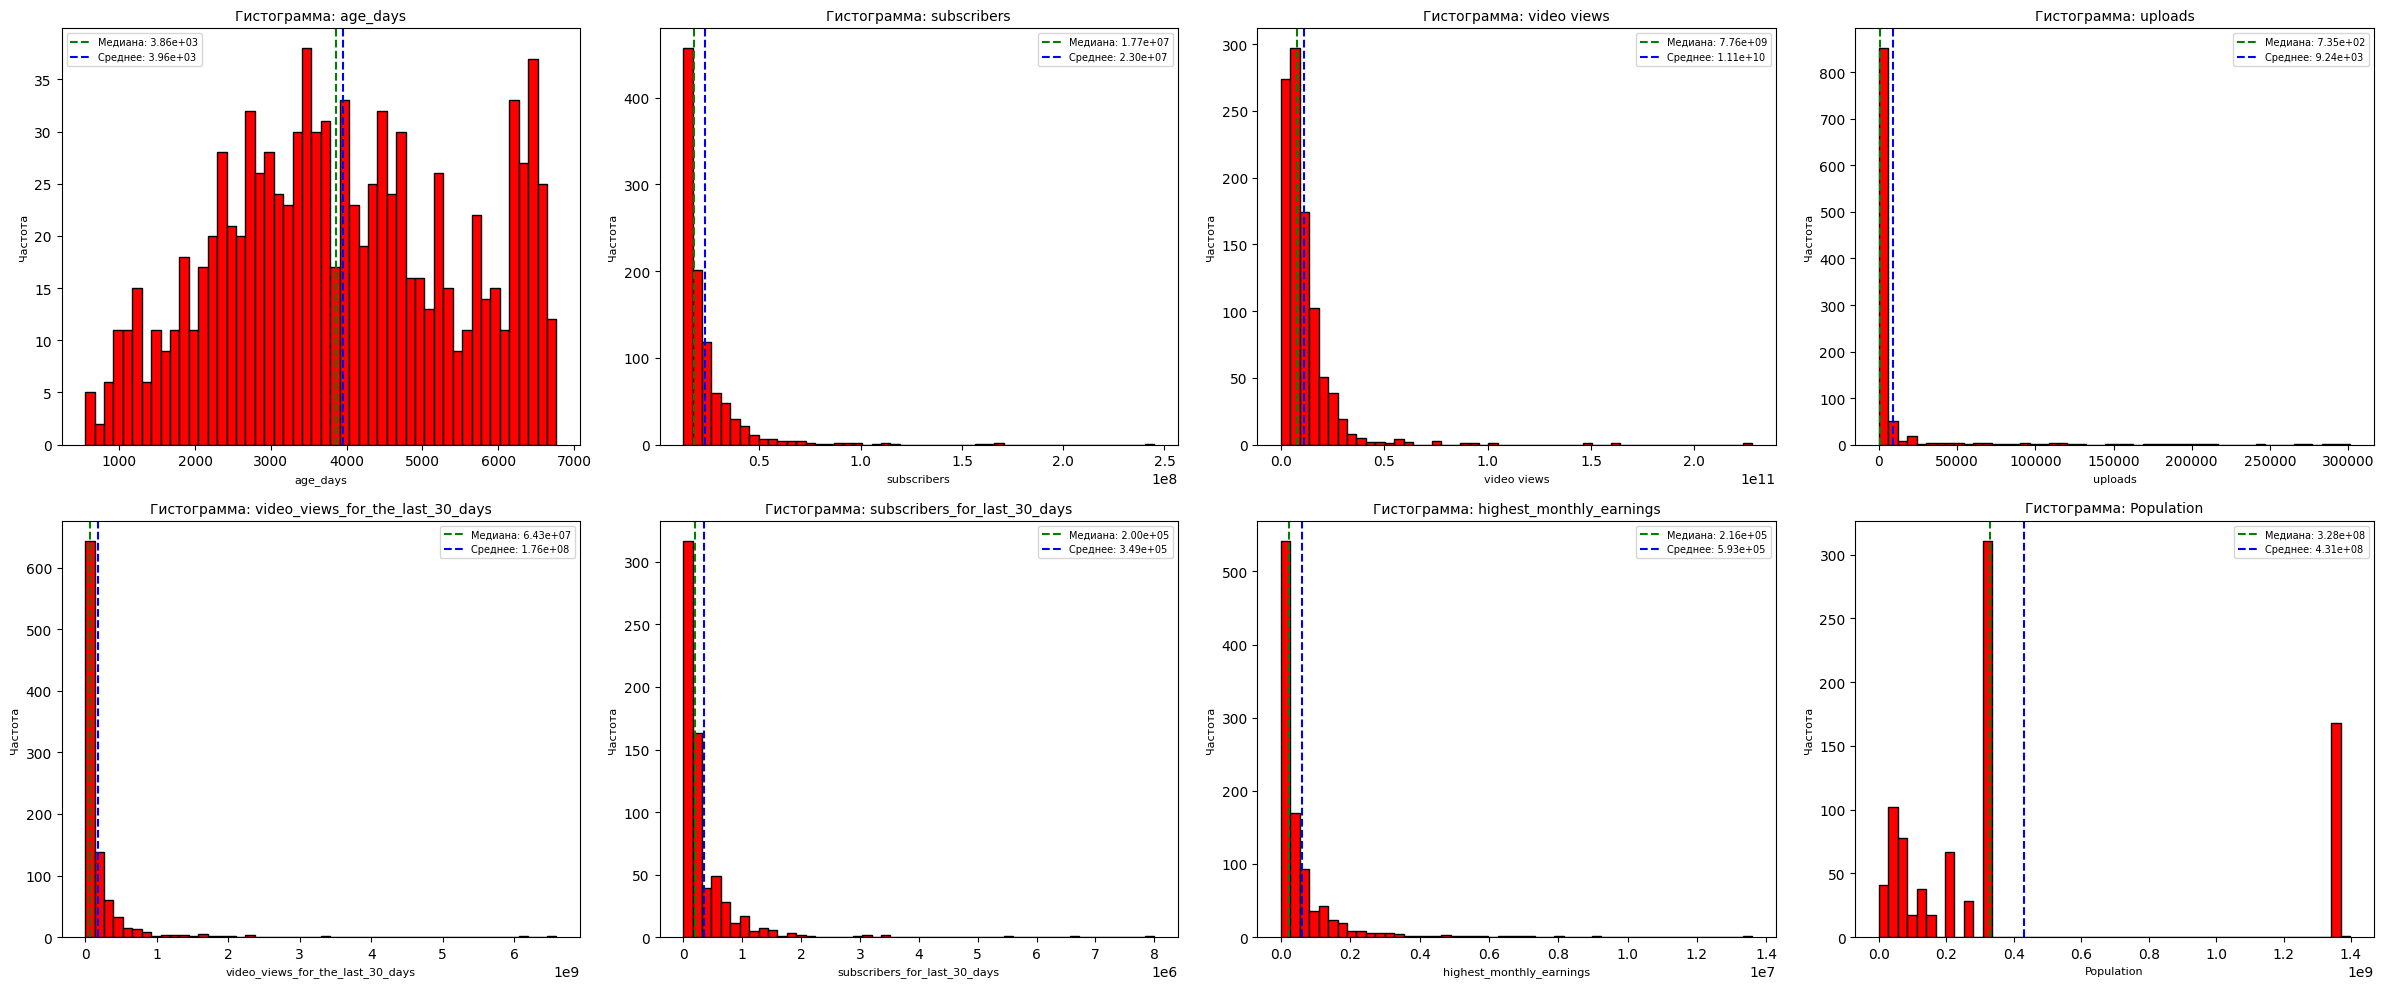

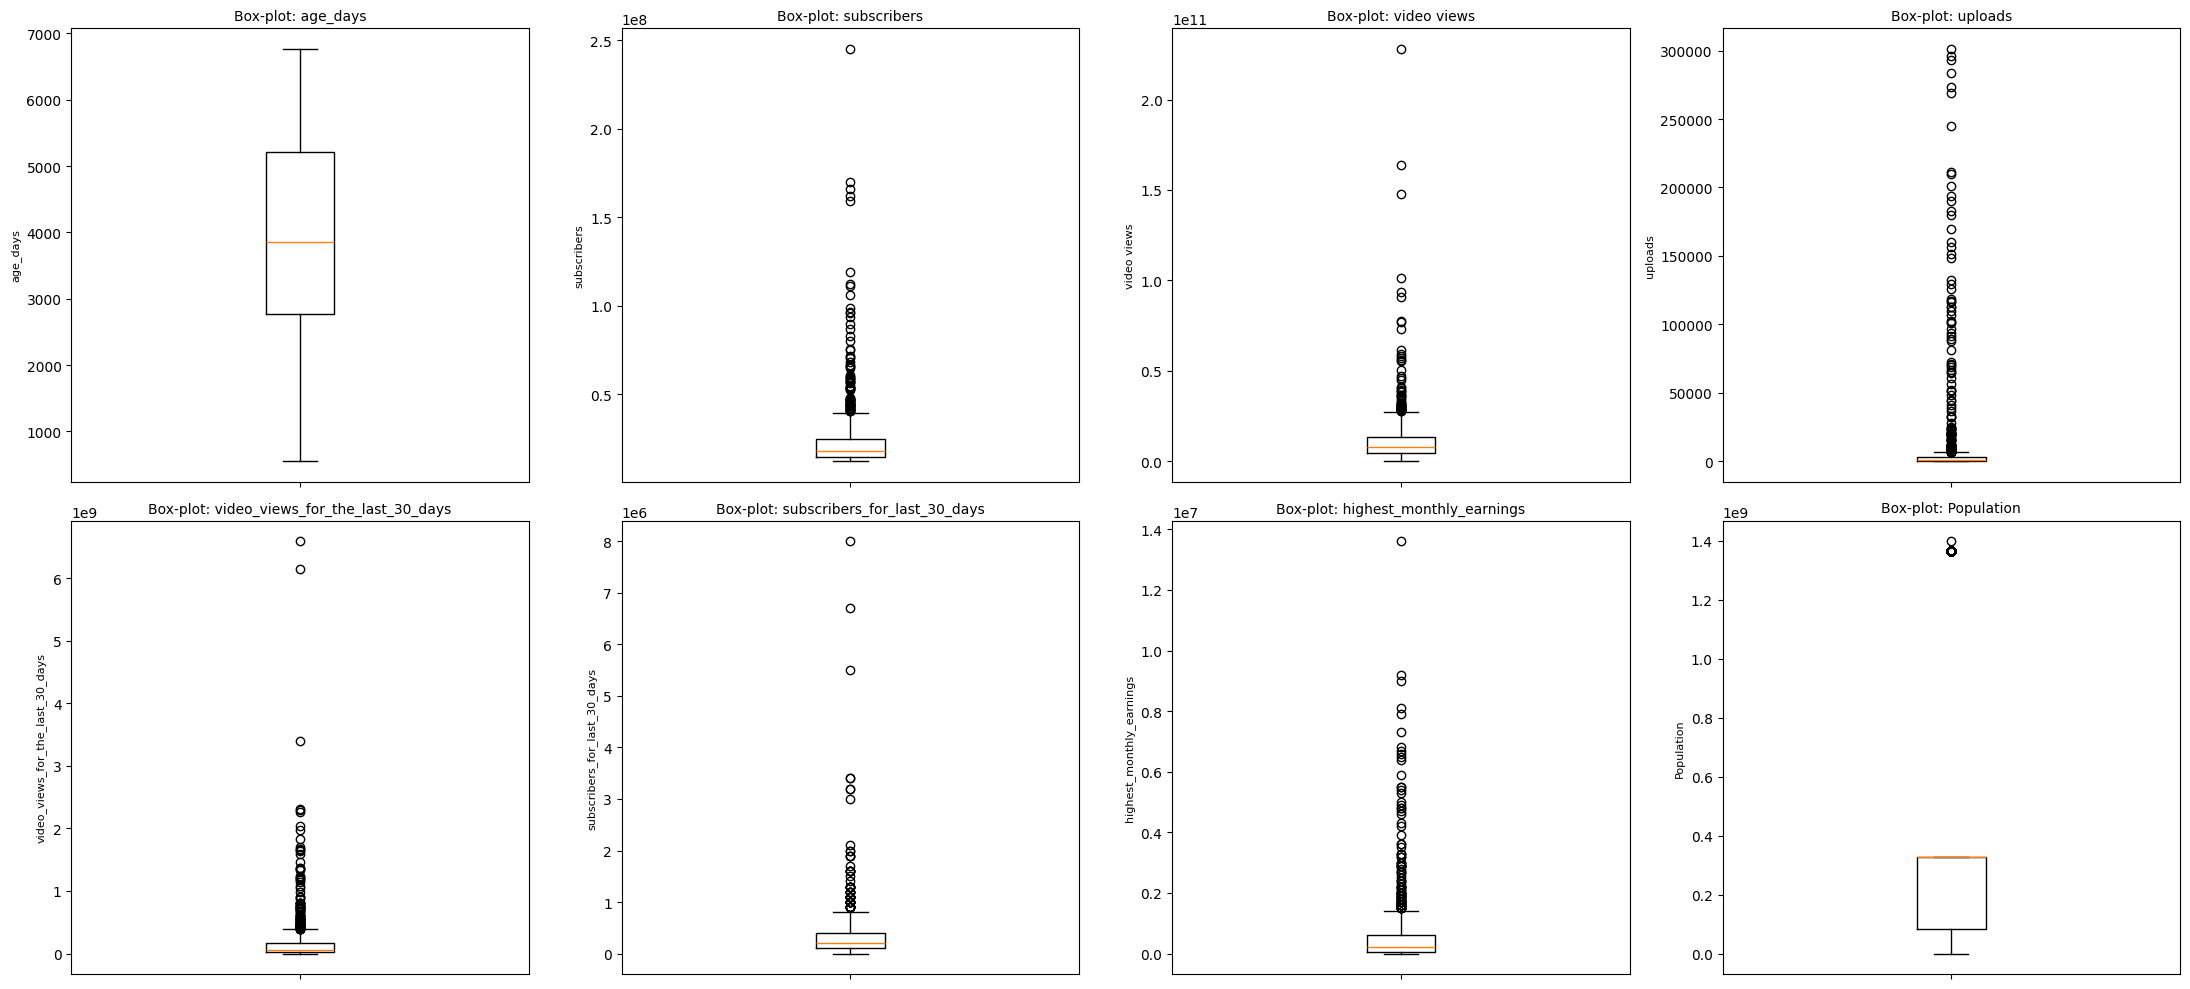

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(24, 10))
axes = axes.flatten()
for i, feature in enumerate(features_numeric):
    clean_data = df_channels[feature].dropna()
    axes[i].hist(clean_data, bins=50, color=color, edgecolor='black')
    axes[i].set_title(f'Гистограмма: {feature}', fontsize=10)
    axes[i].set_xlabel(feature, fontsize=8)
    axes[i].set_ylabel('Частота', fontsize=8)
    axes[i].axvline(clean_data.median(), color='green', linestyle='--', 
                    label=f'Медиана: {clean_data.median():.2e}')
    axes[i].axvline(clean_data.mean(), color='blue', linestyle='--', 
                    label=f'Среднее: {clean_data.mean():.2e}')
    axes[i].legend(fontsize=7)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()
for i, feature in enumerate(features_numeric):
    clean_data = df_channels[feature].dropna()
    axes[i].boxplot(clean_data)
    axes[i].set_title(f'Box-plot: {feature}', fontsize=10)
    axes[i].set_ylabel(feature, fontsize=8)
    axes[i].set_xticklabels([])

plt.tight_layout()
plt.show()

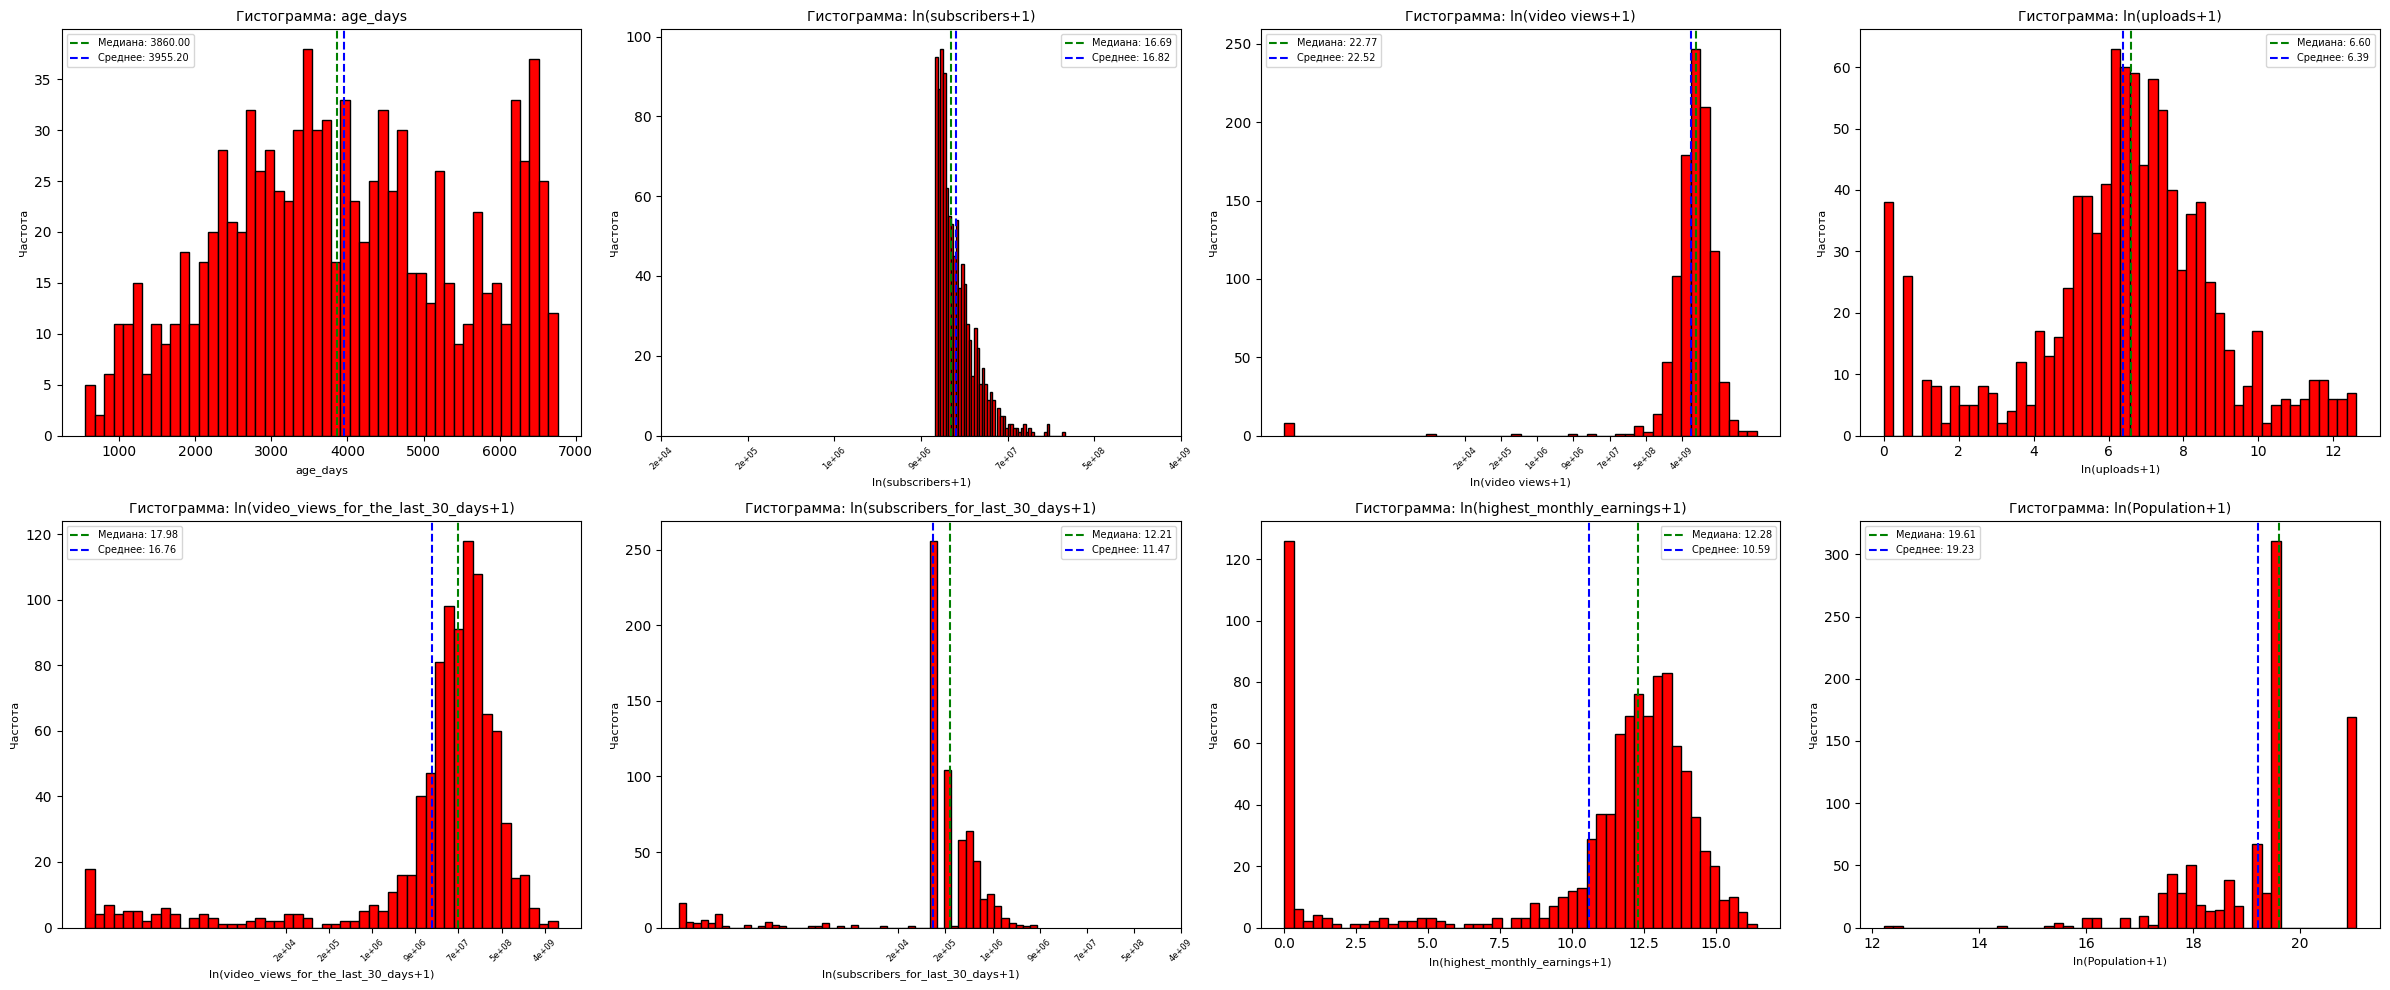

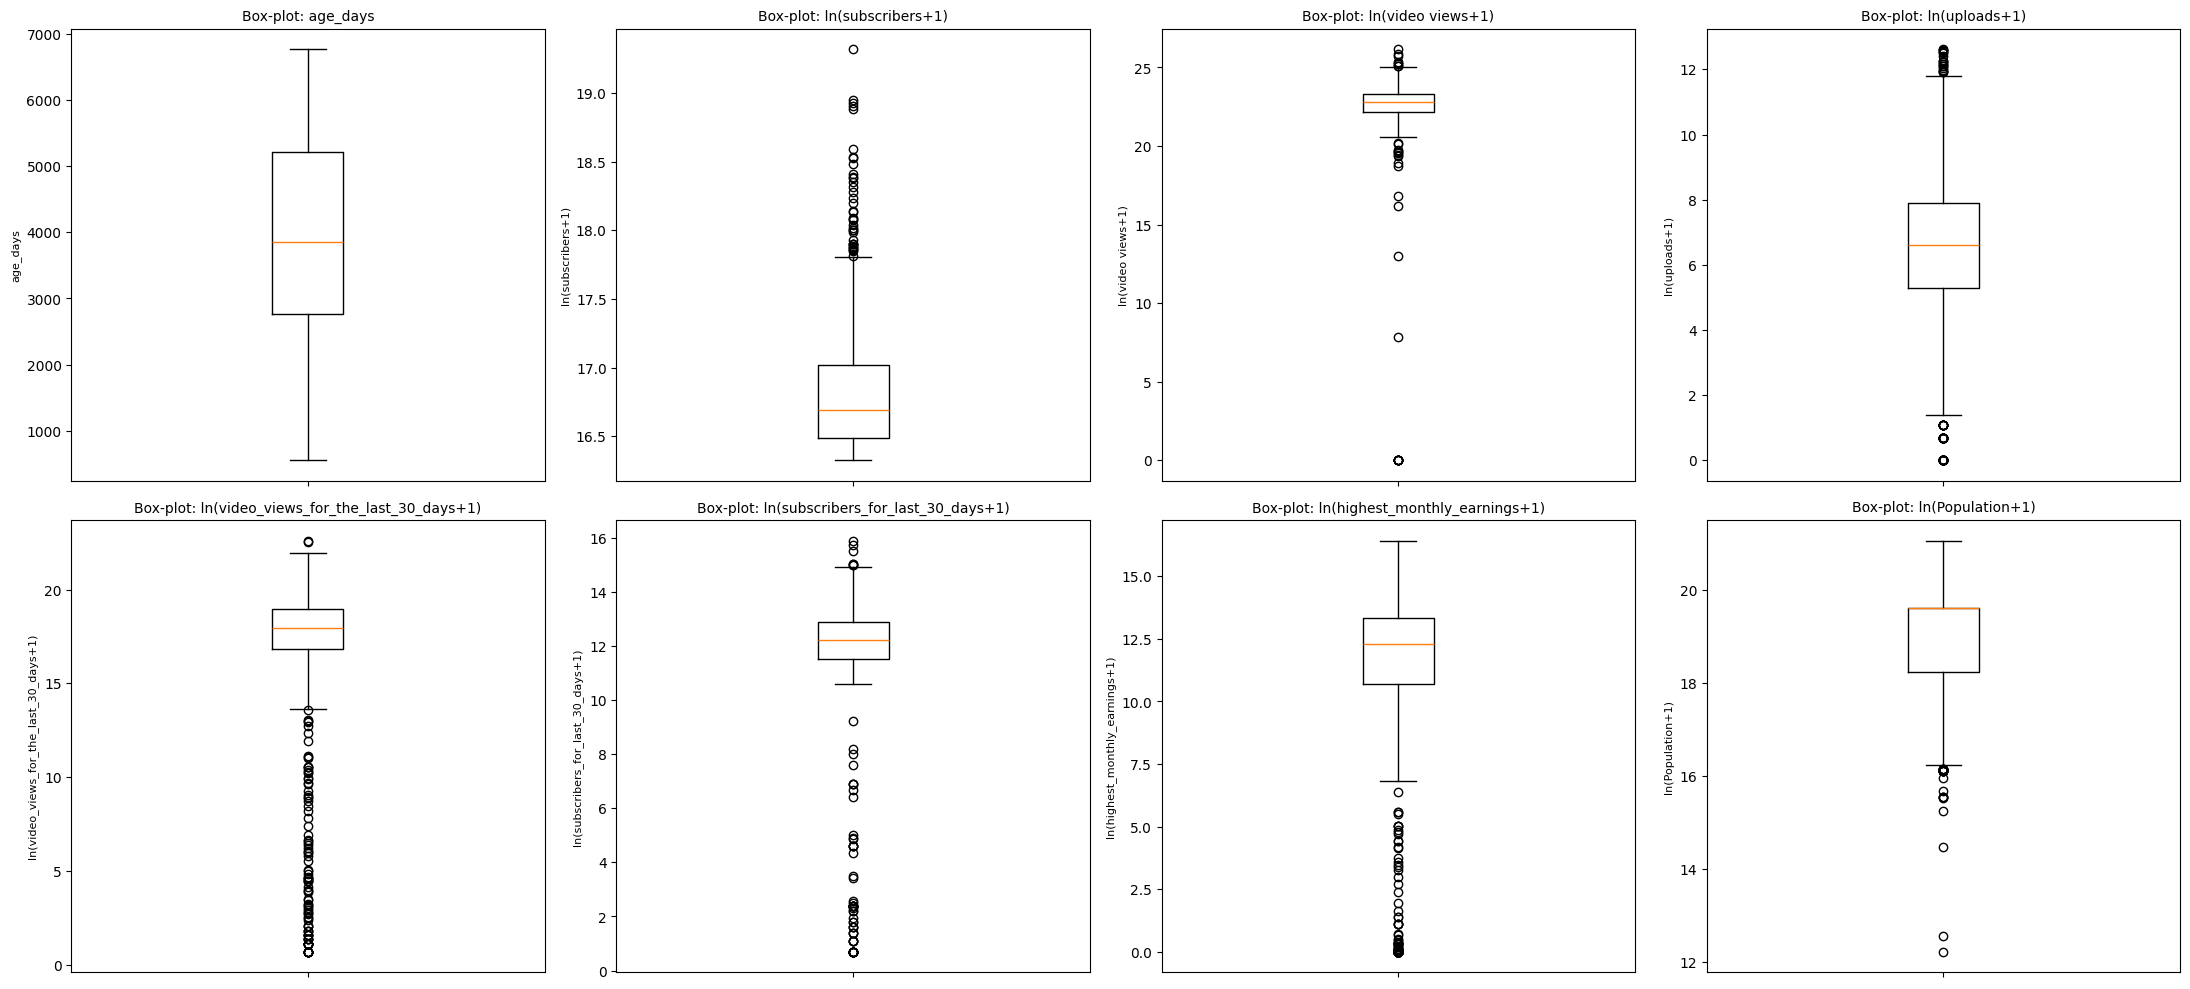

In [8]:
df_log = pd.DataFrame()
log_features = []

for feature in features_numeric:
    if feature != 'age_days':
        log_name = f"{feature}_log"
        df_log[log_name] = np.log1p(df[feature])
        log_features.append(log_name)
    else:
        df_log['age_days'] = df['age_days']
        log_features.append('age_days')

fig, axes = plt.subplots(2, 4, figsize=(24, 10))
axes = axes.flatten()
for i, feature in enumerate(log_features):
    clean_data = df_log[feature].dropna()
    original_name = feature.replace('_log', '')
    axes[i].hist(clean_data, bins=50, color=color, edgecolor='black')
    if feature != 'age_days':
        axes[i].set_title(f'Гистограмма: ln({original_name}+1)', fontsize=10)
        axes[i].set_xlabel(f'ln({original_name}+1)', fontsize=8)
    else:
        axes[i].set_title(f'Гистограмма: {feature}', fontsize=10)
        axes[i].set_xlabel(feature, fontsize=8)
    axes[i].set_ylabel('Частота', fontsize=8)
    
    axes[i].axvline(clean_data.median(), color='green', linestyle='--', 
                    label=f'Медиана: {clean_data.median():.2f}')
    axes[i].axvline(clean_data.mean(), color='blue', linestyle='--', 
                    label=f'Среднее: {clean_data.mean():.2f}')
    axes[i].legend(fontsize=7)
    # Добавляем метки исходных значений для интерпретации (для логарифмированных признаков)
    if feature != 'age_days' and feature != 'Population_log':
        if 'subscribers' in feature or 'views' in feature:
            log_ticks = [10, 12, 14, 16, 18, 20, 22]
            axes[i].set_xticks(log_ticks)
            labels = [f'{np.exp(tick):.0e}' for tick in log_ticks]
            axes[i].set_xticklabels(labels, rotation=45, fontsize=6)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()
for i, feature in enumerate(log_features):
    clean_data = df_log[feature].dropna()
    original_name = feature.replace('_log', '')
    axes[i].boxplot(clean_data)
    if feature != 'age_days':
        axes[i].set_title(f'Box-plot: ln({original_name}+1)', fontsize=10)
        axes[i].set_ylabel(f'ln({original_name}+1)', fontsize=8)
    else:
        axes[i].set_title(f'Box-plot: {feature}', fontsize=10)
        axes[i].set_ylabel(feature, fontsize=8)
    axes[i].set_xticklabels([])
plt.tight_layout()
plt.show()

In [9]:
def stats(df, features):
    results = []
    
    for feature in features:
        data = df[feature].dropna()
        
        Q1 = data.quantile(0.25)
        Q3 = data.quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers = data[(data < lower_bound) | (data > upper_bound)]
        outlier_count = len(outliers)
        outlier_percent = (outlier_count / len(data)) * 100
        
        results.append({
            'Признак': feature,
            'Математическое ожидание (среднее)': data.mean(),
            'Дисперсия': data.var(),
            'Минимум': data.min(),
            'Q1 (25% квартиль)': Q1,
            'Q2 (Медиана)': data.quantile(0.5),
            'Q3 (75% квартиль)': Q3,
            'Максимум': data.max(),
            'IQR': IQR,
            'Нижняя граница': round(lower_bound, 2),
            'Верхняя граница': round(upper_bound, 2),
            'Количество выбросов': outlier_count,
            'Доля выбросов (%)': round(outlier_percent, 2)
        })
    
    results_df = pd.DataFrame(results).set_index('Признак')
    return results_df

channels_stats = stats(df_channels, features_numeric)
channels_stats.T

Признак,age_days,subscribers,video views,uploads,video_views_for_the_last_30_days,subscribers_for_last_30_days,highest_monthly_earnings,Population
Математическое ожидание (среднее),3.955203e+03,2.299414e+07,1.106686e+10,9.242109e+03,1.757750e+08,3.491538e+05,5.933007e+05,4.313397e+08
Дисперсия,2.473455e+06,3.086462e+14,2.000762e+20,1.172895e+09,1.735303e+17,3.780043e+11,1.325315e+12,2.242976e+17
Минимум,5.520000e+02,1.230000e+07,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,2.025060e+05
Q1 (25% квартиль),2.764000e+03,1.450000e+07,4.306213e+09,1.990000e+02,2.007475e+07,1.000000e+05,4.430000e+04,8.335541e+07
Q2 (Медиана),3.860000e+03,1.770000e+07,7.762077e+09,7.350000e+02,6.428700e+07,2.000000e+05,2.160000e+05,3.282395e+08
Q3 (75% квартиль),5.215000e+03,2.460000e+07,1.356285e+10,2.725000e+03,1.689412e+08,4.000000e+05,6.113000e+05,3.282395e+08
Максимум,6.766000e+03,2.450000e+08,2.280000e+11,3.013080e+05,6.589000e+09,8.000000e+06,1.360000e+07,1.397715e+09
IQR,2.451000e+03,1.010000e+07,9.256641e+09,2.526000e+03,1.488665e+08,3.000000e+05,5.670000e+05,2.448841e+08
Нижняя граница,-9.125000e+02,-6.500000e+05,-9.578750e+09,-3.590000e+03,-2.032250e+08,-3.500000e+05,-8.062000e+05,-2.839708e+08
Верхняя граница,8.891500e+03,3.975000e+07,2.744782e+10,6.514000e+03,3.922410e+08,8.500000e+05,1.461800e+06,6.955657e+08


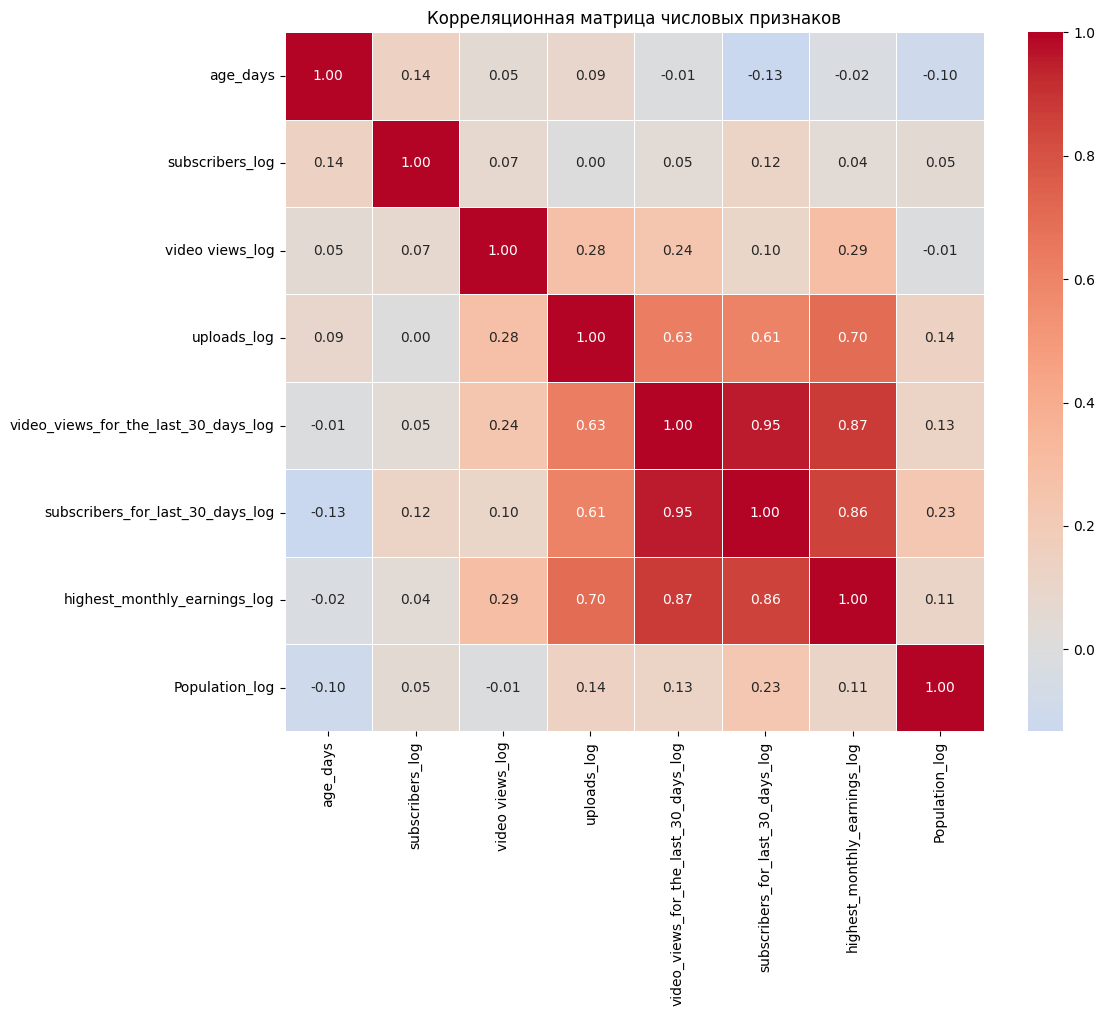

In [14]:
corr_matrix = df_log.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, fmt='.2f')
plt.title('Корреляционная матрица числовых признаков')
plt.tight_layout()
plt.show()

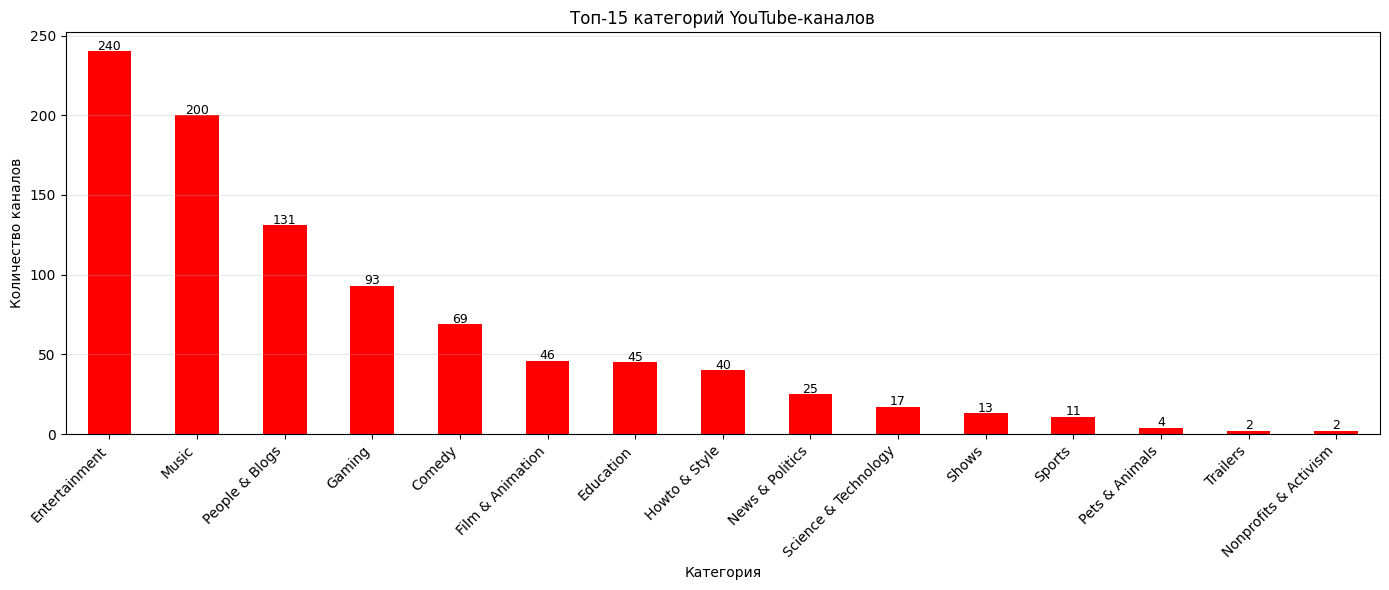

Распределение каналов по категориям:
	Entertainment: 240 видео (24.3%)
	Music: 200 видео (20.2%)
	People & Blogs: 131 видео (13.2%)
	Gaming: 93 видео (9.4%)
	Comedy: 69 видео (7.0%)
	Film & Animation: 46 видео (4.7%)
	Education: 45 видео (4.6%)
	Howto & Style: 40 видео (4.0%)
	News & Politics: 25 видео (2.5%)
	Science & Technology: 17 видео (1.7%)
	Shows: 13 видео (1.3%)
	Sports: 11 видео (1.1%)
	Pets & Animals: 4 видео (0.4%)
	Trailers: 2 видео (0.2%)
	Nonprofits & Activism: 2 видео (0.2%)


In [12]:
plt.figure(figsize=(14, 6))
category_counts = df_channels['category'].value_counts().head(15)
category_counts.plot(kind='bar', color=color)
plt.title('Топ-15 категорий YouTube-каналов')
plt.xlabel('Категория')
plt.ylabel('Количество каналов')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
for i, v in enumerate(category_counts.values):
    plt.text(i, v + 1, str(v), ha='center', fontsize=9)
plt.tight_layout()
plt.show()

print("Распределение каналов по категориям:")
for cat, count in category_counts.sort_values(ascending=False).items():
    print(f"\t{cat}: {count} видео ({count/len(df_channels)*100:.1f}%)")

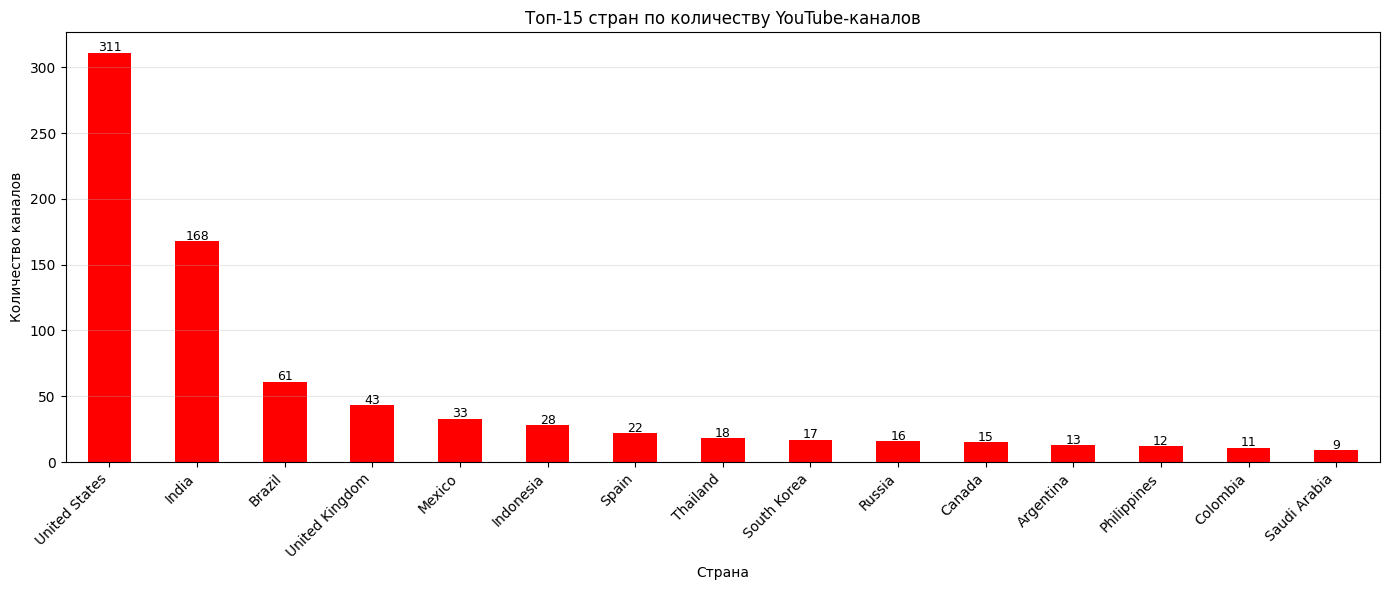

Распределение каналов по странам:
	United States: 311 видео (31.4%)
	India: 168 видео (17.0%)
	Brazil: 61 видео (6.2%)
	United Kingdom: 43 видео (4.3%)
	Mexico: 33 видео (3.3%)
	Indonesia: 28 видео (2.8%)
	Spain: 22 видео (2.2%)
	Thailand: 18 видео (1.8%)
	South Korea: 17 видео (1.7%)
	Russia: 16 видео (1.6%)
	Canada: 15 видео (1.5%)
	Argentina: 13 видео (1.3%)
	Philippines: 12 видео (1.2%)
	Colombia: 11 видео (1.1%)
	Saudi Arabia: 9 видео (0.9%)


In [13]:
plt.figure(figsize=(14, 6))
country_counts = df_channels['Country'].value_counts().head(15)
country_counts.plot(kind='bar', color=color)
plt.title('Топ-15 стран по количеству YouTube-каналов')
plt.xlabel('Страна')
plt.ylabel('Количество каналов')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
for i, v in enumerate(country_counts.values):
    plt.text(i, v + 1, str(v), ha='center', fontsize=9)
plt.tight_layout()
plt.show()

print("Распределение каналов по странам:")
for cat, count in country_counts.sort_values(ascending=False).items():
    print(f"\t{cat}: {count} видео ({count/len(df_channels)*100:.1f}%)")

### 1.3. Предобработка данных

In [14]:
for feature in cluster_features:
    if df[feature].isnull().sum() > 0:
        if feature in features_categorical:
            mode_val = df[feature].mode()[0]
            df[feature] = df[feature].fillna(mode_val, inplace=True)
            print(f"{feature}: заполнено модой ('{mode_val}')")
        elif feature == 'Population':
            mode_val = df[feature].mode()[0]
            df[feature] = df[feature].fillna(mode_val, inplace=True)
            print(f"{feature}: заполнено модой ('{mode_val}')")
        elif feature in ['video_views_for_the_last_30_days', 'subscribers_for_last_30_days', 'highest_monthly_earnings']:
            df[feature] = df[feature].fillna(0, inplace=True)
            print(f"{feature}: заполнено 0")
        else:
            median_val = df[feature].median()
            df[feature] = df[feature].fillna(median_val, inplace=True)
            print(f"{feature}: заполнено медианой ({median_val:.2e})")

df.isnull().sum()

category: заполнено модой ('Entertainment')
channel_type: заполнено модой ('Entertainment')
video_views_for_the_last_30_days: заполнено 0
subscribers_for_last_30_days: заполнено 0
Country: заполнено модой ('United States')
Population: заполнено модой ('328239523.0')


category                            0
channel_type                        0
age_days                            0
subscribers                         0
video views                         0
uploads                             0
video_views_for_the_last_30_days    0
subscribers_for_last_30_days        0
highest_monthly_earnings            0
Country                             0
Population                          0
dtype: int64

In [15]:
label_encoders = {}
for feature in features_categorical:
    le = LabelEncoder()
    df[feature + '_encoded'] = le.fit_transform(df[feature].astype(str))
    label_encoders[feature] = le
    df = df.drop(feature, axis=1)
    print(f"{feature}: закодировано {len(le.classes_)} уникальных категорий")

category: закодировано 18 уникальных категорий
channel_type: закодировано 14 уникальных категорий
Country: закодировано 49 уникальных категорий


In [16]:
df

,age_days,subscribers,video views,uploads,video_views_for_the_last_30_days,subscribers_for_last_30_days,highest_monthly_earnings,Population,category_encoded,channel_type_encoded,Country_encoded
0,6502,245000000,2.280000e+11,20082,2.258000e+09,2000000.0,9000000.00,1.366418e+09,8,8,18
1,6510,170000000,0.000000e+00,1,1.200000e+01,0.0,0.05,3.282395e+08,4,6,46
2,4332,166000000,2.836884e+10,741,1.348000e+09,8000000.0,5400000.00,3.282395e+08,3,4,46
3,6330,162000000,1.640000e+11,966,1.975000e+09,1000000.0,7900000.00,3.282395e+08,2,3,46
4,6311,159000000,1.480000e+11,116536,1.824000e+09,1000000.0,7300000.00,1.366418e+09,14,4,18
...,...,...,...,...,...,...,...,...,...,...,...
990,2513,12300000,9.029610e+09,1200,5.525130e+08,700000.0,2200000.00,2.125594e+08,15,4,6
991,1934,12300000,1.674410e+09,1500,6.473500e+07,300000.0,258900.00,1.366418e+09,11,6,18
992,6320,12300000,2.214684e+09,2452,6.703500e+04,1000.0,268.00,6.683440e+07,3,6,45
993,4253,12300000,3.741235e+08,39,3.871000e+06,100000.0,15500.00,1.028545e+07,5,6,39


### 1.4. Нормализация и стандартизация данных

In [17]:
print(f"\n{BOLD}Логарифмическое преобразование{END} применено к признакам:")
log_features = features_numeric.copy()
log_features.remove('age_days')
for feature in log_features:
    df[feature + '_log'] = np.log1p(df[feature])
    df = df.drop(feature, axis=1)
    print(f"\t{feature} → {feature}_log")

print(f"\n{BOLD}Стандартизация (Z-масштабирование){END} применена к признакам:")
scale_features = [feature + '_log' for feature in log_features]
scale_features.append('age_days')
scaler = StandardScaler()
df[scale_features] = scaler.fit_transform(df[scale_features])
print('\t' + '\n\t'.join(scale_features))


Логарифмическое преобразование применено к признакам:
	subscribers → subscribers_log
	video views → video views_log
	uploads → uploads_log
	video_views_for_the_last_30_days → video_views_for_the_last_30_days_log
	subscribers_for_last_30_days → subscribers_for_last_30_days_log
	highest_monthly_earnings → highest_monthly_earnings_log
	Population → Population_log

Стандартизация (Z-масштабирование) применена к признакам:
	subscribers_log
	video views_log
	uploads_log
	video_views_for_the_last_30_days_log
	subscribers_for_last_30_days_log
	highest_monthly_earnings_log
	Population_log
	age_days


## 3 Решение задачи кластеризации

### 3.1 Метод k-средних 

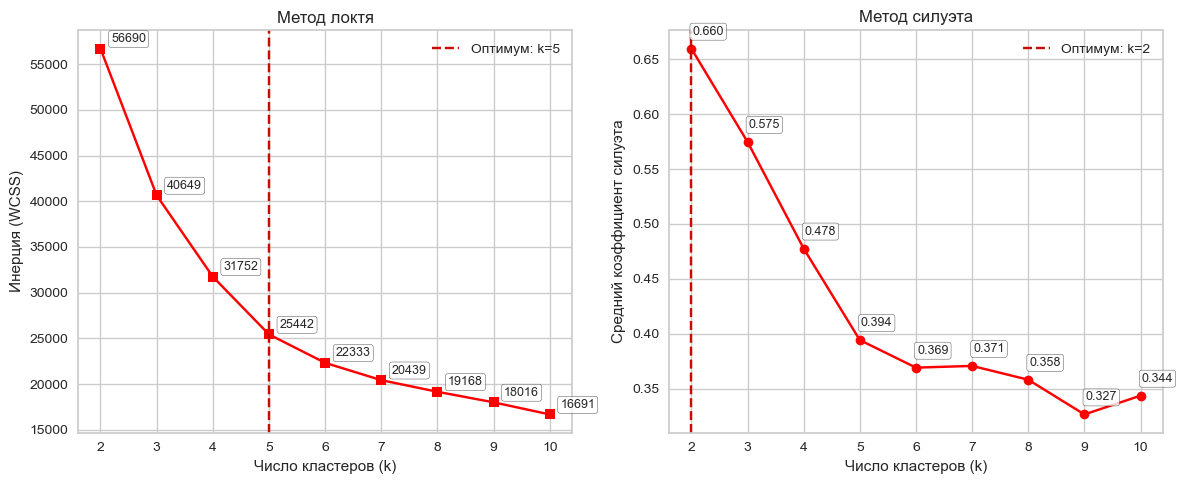

In [ ]:
k_range = range(2, 11)
inertias = []
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(df, kmeans.labels_))
    
plt.figure(figsize=(12, 5))

# Визуализация метода локтя
plt.subplot(1, 2, 1)
plt.plot(k_range, inertias, marker='s', color=color)
plt.title('Метод локтя')
plt.xlabel('Число кластеров (k)')
plt.ylabel('Инерция (WCSS)')
plt.grid(True)

for i, (k, inertia) in enumerate(zip(k_range, inertias)):
    plt.annotate(f'{inertia:.0f}', 
                xy=(k, inertia), 
                xytext=(k + 0.5, inertia + 400),
                ha='center', 
                va='bottom',
                fontsize=9,
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8))

optimal_k_elbow = KneeLocator(k_range, inertias, curve='convex', direction='decreasing').elbow
plt.axvline(x=optimal_k_elbow, color='r', linestyle='--', label=f'Оптимум: k={optimal_k_elbow}')
plt.legend()

# Визуализация метода силуэта
plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_scores, marker='o', color=color)
plt.title('Метод силуэта')
plt.xlabel('Число кластеров (k)')
plt.ylabel('Средний коэффициент силуэта')
plt.grid(True)

for i, (k, score) in enumerate(zip(k_range, silhouette_scores)):
    plt.annotate(f'{score:.3f}', 
                xy=(k, score), 
                xytext=(k + 0.3, score + 0.01),
                ha='center', 
                va='bottom',
                fontsize=9,
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8))

optimal_k_silhouette = k_range[np.argmax(silhouette_scores)]
plt.axvline(x=optimal_k_silhouette, color='r', linestyle='--', label=f'Оптимум: k={optimal_k_silhouette}')
plt.legend()

plt.tight_layout()
plt.show()

In [193]:
optimal_k = optimal_k_elbow
optimal_k

5

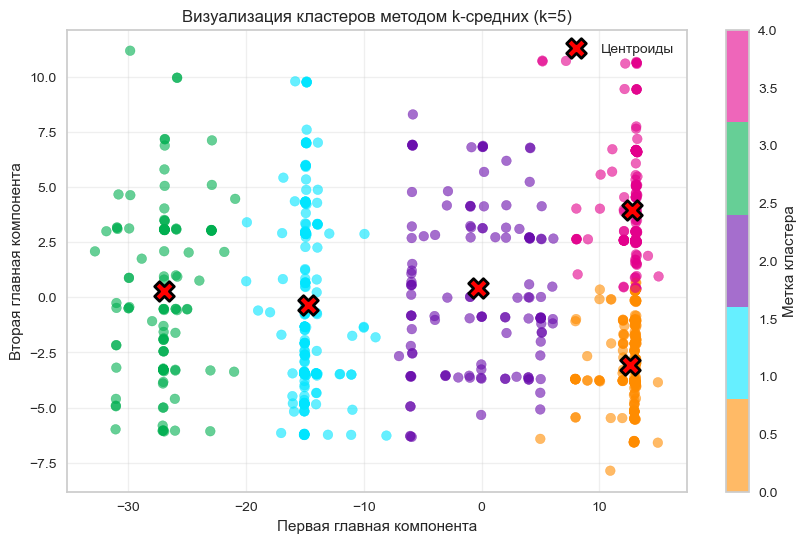

In [ ]:
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(df)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(df)
centroids_pca = pca.transform(kmeans.cluster_centers_)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, 
                      cmap=colors, alpha=0.6)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], 
            marker='X', s=200, linewidths=2, 
            color='red', edgecolors='black', label='Центроиды')
plt.title(f'Визуализация кластеров методом k-средних (k={optimal_k})')
plt.xlabel('Первая главная компонента')
plt.ylabel('Вторая главная компонента')
plt.colorbar(scatter, label='Метка кластера')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 3.2 Агломеративная кластеризация. Метод Уорда 

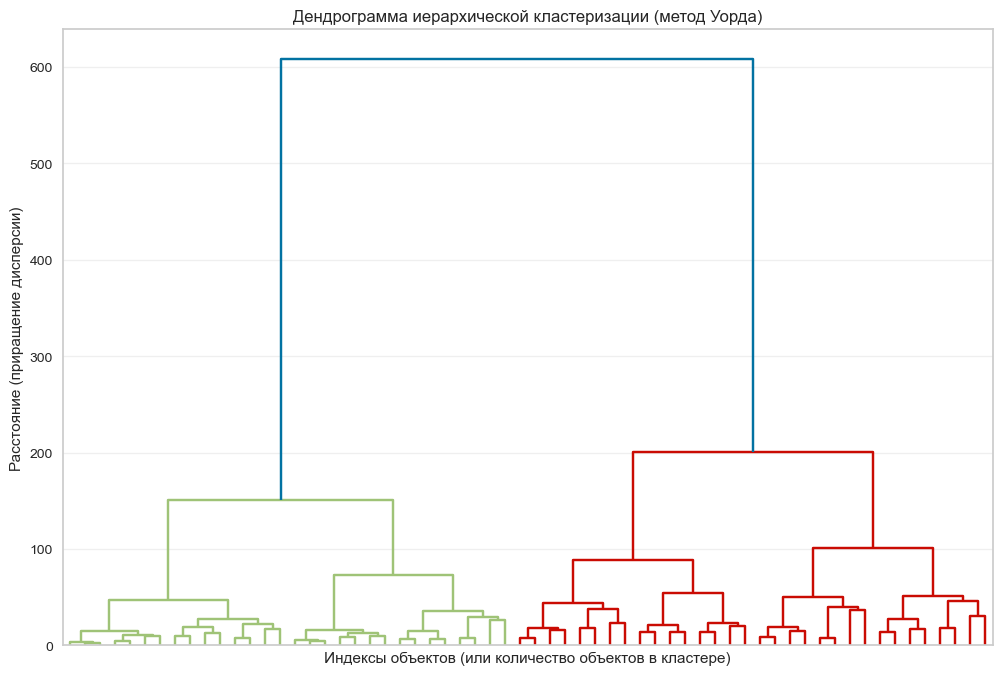

In [ ]:
Z = linkage(df, method='ward', metric='euclidean')

plt.figure(figsize=(12, 8))
dendrogram(Z, truncate_mode='level', p=5, no_labels=True)
plt.title('Дендрограмма иерархической кластеризации (метод Уорда)')
plt.xlabel('Индексы объектов (или количество объектов в кластере)')
plt.ylabel('Расстояние (приращение дисперсии)')
plt.grid(True, axis='y', alpha=0.3)
plt.show()

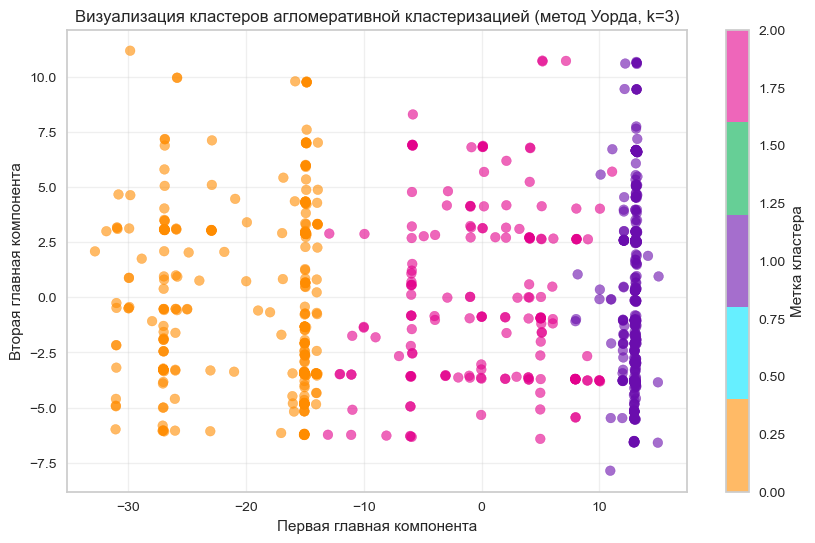

In [ ]:
agg_clustering = AgglomerativeClustering(n_clusters=3, linkage='ward')
agg_labels = agg_clustering.fit_predict(df)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=agg_labels, 
                      cmap=colors, alpha=0.6)
plt.title(f'Визуализация кластеров агломеративной кластеризацией (метод Уорда, k={3})')
plt.xlabel('Первая главная компонента')
plt.ylabel('Вторая главная компонента')
plt.colorbar(scatter, label='Метка кластера')
plt.grid(True, alpha=0.3)
plt.show()

### 3.3 Плотностные алгоритмы DBSCAN и OPTICS

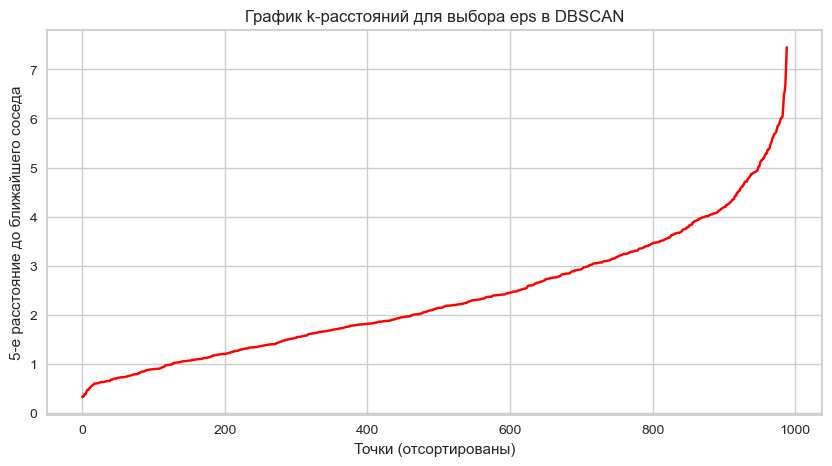

In [ ]:
min_samples_val = 5
k = min_samples_val
neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(df)
distances, indices = neighbors_fit.kneighbors(df)

k_dist = np.sort(distances[:, k-1], axis=0)

plt.figure(figsize=(10, 5))
plt.plot(k_dist, color=color)
plt.title('График k-расстояний для выбора eps в DBSCAN')
plt.xlabel('Точки (отсортированы)')
plt.ylabel(f'{k}-е расстояние до ближайшего соседа')
plt.grid(True)
plt.show()

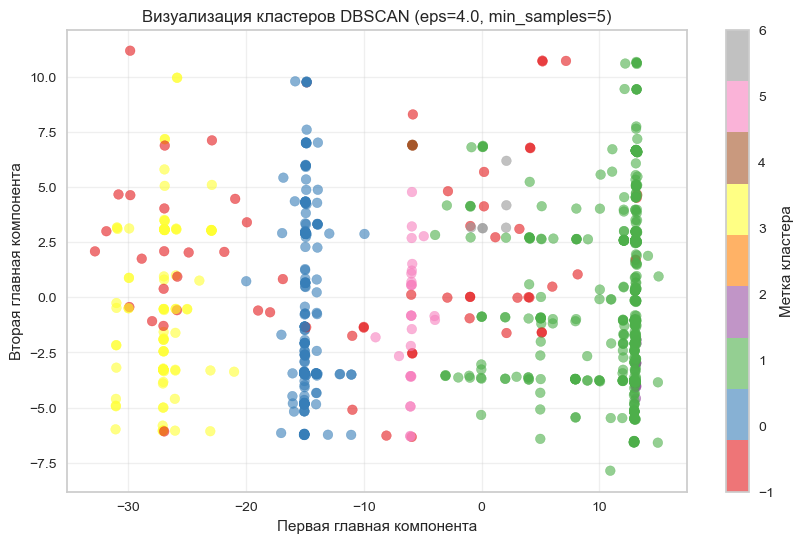

Метки кластеров: [-1  0  1  2  3  4  5  6]
Шумы (кластер -1): 62 (6.27%)


In [ ]:
eps_val = 4.0
dbscan = DBSCAN(eps=eps_val, min_samples=min_samples_val)
dbscan_labels = dbscan.fit_predict(df)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=dbscan_labels, 
                      cmap='Set1', alpha=0.6)
plt.title(f'Визуализация кластеров DBSCAN (eps={eps_val}, min_samples={min_samples_val})')
plt.xlabel('Первая главная компонента')
plt.ylabel('Вторая главная компонента')
plt.colorbar(scatter, label='Метка кластера')
plt.grid(True, alpha=0.3)
plt.show()

print(f"Метки кластеров: {np.unique(dbscan_labels)}")
noises = np.sum(dbscan_labels == -1)
print(f"Шумы (кластер -1): {noises} ({noises/len(dbscan_labels)*100:.2f}%)")

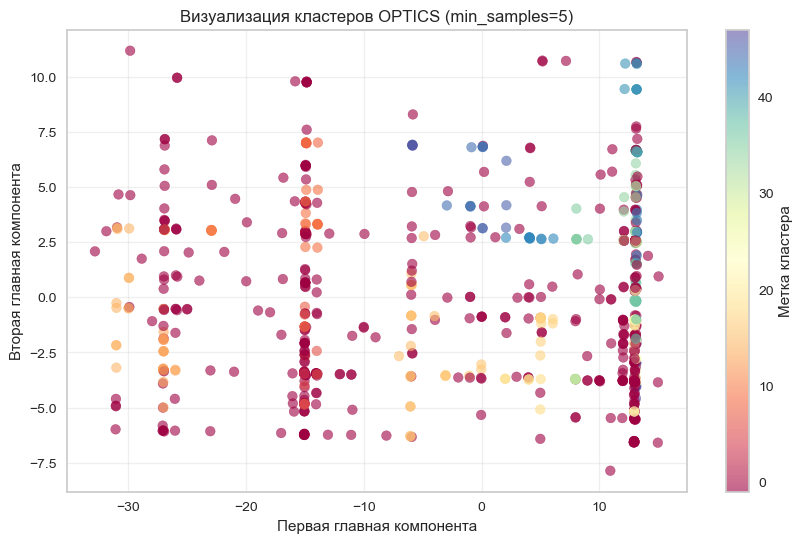

Метки кластеров: [-1  0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22
 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46
 47]
Шумы (кластер -1): 568 (57.43%)


In [ ]:
optics = OPTICS(min_samples=min_samples_val)
optics_labels = optics.fit_predict(df)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=optics_labels, 
                      cmap='Spectral', alpha=0.6)
plt.title(f'Визуализация кластеров OPTICS (min_samples={min_samples_val})')
plt.xlabel('Первая главная компонента')
plt.ylabel('Вторая главная компонента')
plt.colorbar(scatter, label='Метка кластера')
plt.grid(True, alpha=0.3)
plt.show()

print(f"Метки кластеров: {np.unique(optics_labels)}")
noises = np.sum(optics_labels == -1)
print(f"Шумы (кластер -1): {noises} ({noises/len(optics_labels)*100:.2f}%)")